In [ ]:
import importlib
import subprocess
import sys

REQUIRED = {
    "cv2":          "opencv-python-headless",
    "skimage":      "scikit-image",
    "sklearn":      "scikit-learn",
    "PIL":          "Pillow",
    "matplotlib":   "matplotlib",
    "seaborn":      "seaborn",
    "pandas":       "pandas",
    "numpy":        "numpy",
    "tqdm":         "tqdm",
    "dotenv":       "python-dotenv",
    "yaml":         "PyYAML",
    "gdown":        "gdown",
}

missing = {pip for mod, pip in REQUIRED.items() if importlib.util.find_spec(mod) is None}

if missing:
    print(f"Instalando paquetes faltantes: {', '.join(sorted(missing))}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *sorted(missing)])
    print("Instalación completada. Si hay errores de importación más abajo, reinicia el kernel.")
else:
    print("Todas las dependencias están disponibles.")


Todas las dependencias están disponibles.


# 1. Análisis Exploratorio de Datos (EDA)
## Proyecto: Clasificación de Enfermedades en Hoja de Maíz

---

## Objetivo

Comprender la composición del dataset consolidado en `data/clean/`, identificar problemas potenciales (desbalance, sesgos de captura, duplicados, calidad de imagen) y justificar las decisiones de preprocesamiento y entrenamiento del modelo.

---

## 1.1 Documentación general del dataset

### Ficha técnica

| Campo | Valor |
|---|---|
| **Total de imágenes** | 25 285 |
| **Número de clases** | 9 |
| **Directorio base** | `data/clean/` |
| **Tamaño total en disco** | ~14.3 GB |

---

### Descripción de clases

#### Enfermedades foliares

| Clase | Nombre científico | Total | Lab | Real |
|---|---|---:|---:|---:|
| `common_rust` | *Puccinia sorghi* | 2 256 | 2 150 | 106 |
| `northern_corn_leaf_blight` | *Exserohilum turcicum* | 6 830 | 888 | 5 942 |
| `gray_leaf_spot` | *Cercospora zeae-maydis* | 1 119 | 513 | 606 |
| `healthy` | — | 8 744 | 0 | 8 744 |

#### Plagas

| Clase | Nombre científico | Total | Lab | Real |
|---|---|---:|---:|---:|
| `fall_armyworm` | *Spodoptera frugiperda* | 4 858 | 0 | 4 858 |
| `aphids_pest` | *Rhopalosiphum maidis* | 77 | 0 | 77 |

#### Deficiencias nutricionales

| Clase | Total | Lab | Real |
|---|---:|---:|---:|
| `nitrogen_deficiency` | 523 | 0 | 523 |
| `phosphorus_deficiency` | 612 | 0 | 612 |
| `potassium_deficiency` | 266 | 0 | 266 |

---

### Procedencia de las imágenes

Las imágenes provienen de **datasets públicos**. No se incluyen capturas propias. Los datasets de origen son:

| Identificador | Dataset original | Fuente |
|---|---|---|
| `corn_leaf_roboflow` | corn-leaf-roboflow | Roboflow Universe |
| `cropdg` | cropdg-unified-multidomain | CropDG (PlantVillage subset) |
| `maize_africa` | maize-beans-tomatoes-africa | Kaggle |
| `maize_desease` | maize-diseases | Kaggle |
| `maize_field` | maize-in-field-dataset | Kaggle |
| `maize_nutrient` | maize-nutrient-deficiency | Kaggle |

> **Descartados:** `corn-leaf-diseases` (imágenes augmentadas sin originales) y `multicrop-disease` (mezcla destructiva de entornos y preprocesados sin estructura).

---

### Condiciones de captura

| Contexto | Descripción |
|---|---|
| **`lab`** | Fondo uniforme (negro/blanco/gris), entorno controlado, iluminación artificial, distancia corta y constante. Típico de PlantVillage. |
| **`real`** | Campo abierto, fondo natural variable, iluminación solar (variable), diversidad de distancias y ángulos. |

- **Resolución:** heterogénea. Las imágenes de `corn_leaf_roboflow` ya vienen redimensionadas a **640 × 640 px** (Roboflow). El resto conserva resolución original.
- **Formato:** predominantemente JPEG/JPG, algunos PNG.
- **Naming convention:** `<clase>_<origen>_<tipo>_<correlativo>.<ext>`

In [2]:
import os
from pathlib import Path
from dotenv import load_dotenv
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import random

GDRIVE_FILE_ID = "16eZnMhSs3LIvwAdpPKg3uyghAn0Giu4T"

load_dotenv(Path.cwd().parent / ".env")
_ENV_ROOT = os.getenv("DATASET_ROOT")

if _ENV_ROOT and Path(_ENV_ROOT).exists():
    DATASET_ROOT = Path(_ENV_ROOT)
    print(f"Entorno: servidor/local (DATASET_ROOT={DATASET_ROOT})")
else:
    # Google Colab
    DATASET_ROOT = Path("/content/corn-leaf-diseases")

    if not (DATASET_ROOT / "clean").exists():
        import gdown, zipfile
        ZIP = Path("/content/corn-leaf-diseases-clean.zip")

        if not ZIP.exists():
            print("Descargando dataset (~14 GB)...")
            gdown.download(id=GDRIVE_FILE_ID, output=str(ZIP), quiet=False)

        print("Descomprimiendo...")
        with zipfile.ZipFile(ZIP, "r") as zf:
            zf.extractall("/content/corn-leaf-diseases")
        ZIP.unlink()
        print("Listo.")

    print("Entorno: Google Colab")

DATA_DIR = str(DATASET_ROOT / "clean")

if not Path(DATA_DIR).exists():
    raise FileNotFoundError(
        f"No se encontró {DATA_DIR}\n"
        "Verifica que DATASET_ROOT en .env apunte al dataset, o que el archivo de Drive sea accesible públicamente."
    )

print(f"Dataset root: {DATASET_ROOT}")
print(f"Clean dir:    {DATA_DIR}")

# Verificar clases dinámicamente
class_names = [d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))]
print(f"Clases encontradas ({len(class_names)}): {class_names}")

# Configuración visual para los gráficos
sns.set_theme(style="whitegrid")

Descargando dataset (~14 GB)...


Downloading...
From (original): https://drive.google.com/uc?id=16eZnMhSs3LIvwAdpPKg3uyghAn0Giu4T
From (redirected): https://drive.google.com/uc?id=16eZnMhSs3LIvwAdpPKg3uyghAn0Giu4T&confirm=t&uuid=bc252787-3826-4092-8f57-2b0e046bd0e0
To: /content/corn-leaf-diseases-clean.zip
100%|██████████| 15.3G/15.3G [03:54<00:00, 65.2MB/s]


Descomprimiendo...
Listo.
Entorno: Google Colab
Dataset root: /content/corn-leaf-diseases
Clean dir:    /content/corn-leaf-diseases/clean
Clases encontradas (9): ['fall_armyworm', 'aphids_pest', 'healthy', 'gray_leaf_spot', 'potassium_deficiency', 'northern_corn_leaf_blight', 'nitrogen_deficiency', 'phosphorus_deficiency', 'common_rust']


---

## 1.2 Análisis de distribución de clases

Es fundamental identificar si el conjunto de datos presenta un desbalance significativo. Un desbalance severo puede provocar que el modelo se sesgue hacia la clase mayoritaria (ej. `healthy`), ignorando las enfermedades menos representadas.

Adicionalmente se desglosa el conteo entre imágenes de **laboratorio** (`lab/`) e imágenes de **campo** (`real/`), dado que ambos entornos de captura representan distribuciones visuales muy distintas y su proporción afecta directamente el riesgo de sesgo por dominio.

Total de imágenes: 25,284

                    clase  lab  real  total  porcentaje
                  healthy    0  8744   8744       34.58
northern_corn_leaf_blight  888  5942   6830       27.01
            fall_armyworm    0  4857   4857       19.21
              common_rust 2150   106   2256        8.92
           gray_leaf_spot  513   606   1119        4.43
    phosphorus_deficiency    0   612    612        2.42
      nitrogen_deficiency    0   523    523        2.07
     potassium_deficiency    0   266    266        1.05
              aphids_pest    0    77     77        0.30


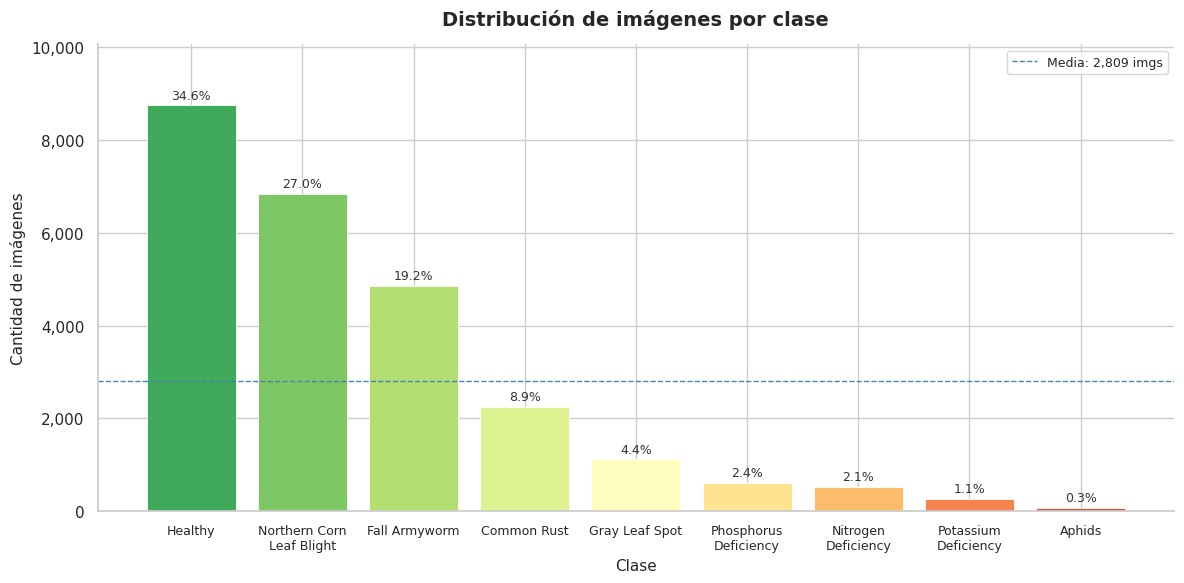

In [3]:
from pathlib import Path
import matplotlib.ticker as mticker
import numpy as np

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def count_images(directory: Path) -> int:
    return sum(1 for f in directory.rglob("*") if f.suffix.lower() in IMG_EXTS)

CLEAN_DIR = Path(DATA_DIR)

records = []
for class_dir in sorted(CLEAN_DIR.iterdir()):
    if not class_dir.is_dir():
        continue
    lab_dir  = class_dir / "lab"
    real_dir = class_dir / "real"
    lab_count  = count_images(lab_dir)  if lab_dir.is_dir()  else 0
    real_count = count_images(real_dir) if real_dir.is_dir() else 0
    records.append({
        "clase":   class_dir.name,
        "lab":     lab_count,
        "real":    real_count,
        "total":   lab_count + real_count,
    })

df = pd.DataFrame(records).sort_values("total", ascending=False).reset_index(drop=True)
total_imgs = df["total"].sum()
df["porcentaje"] = (df["total"] / total_imgs * 100).round(2)

print(f"Total de imágenes: {total_imgs:,}\n")
print(df.to_string(index=False))

LABEL_MAP = {
    "healthy":                    "Healthy",
    "northern_corn_leaf_blight":  "Northern Corn\nLeaf Blight",
    "fall_armyworm":              "Fall Armyworm",
    "common_rust":                "Common Rust",
    "gray_leaf_spot":             "Gray Leaf Spot",
    "phosphorus_deficiency":      "Phosphorus\nDeficiency",
    "nitrogen_deficiency":        "Nitrogen\nDeficiency",
    "potassium_deficiency":       "Potassium\nDeficiency",
    "aphids_pest":                "Aphids",
}
df["label"] = df["clase"].map(LABEL_MAP).fillna(df["clase"])

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, len(df)))
bars = ax.bar(df["label"], df["total"], color=colors, edgecolor="white", linewidth=0.6)

for bar, pct in zip(bars, df["porcentaje"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 80,
        f"{pct:.1f}%",
        ha="center", va="bottom", fontsize=9, color="#333333",
    )

ax.set_title("Distribución de imágenes por clase", fontsize=14, fontweight="bold", pad=14)
ax.set_xlabel("Clase", fontsize=11)
ax.set_ylabel("Cantidad de imágenes", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_ylim(0, df["total"].max() * 1.15)
ax.tick_params(axis="x", labelsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.axhline(total_imgs / len(df), color="steelblue", linestyle="--", linewidth=1,
           label=f"Media: {total_imgs // len(df):,} imgs")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("../tmp/eda_01_distribucion_clases.png", dpi=150, bbox_inches="tight")
plt.show()

---

## 1.3 Análisis de origen de las imágenes (lab vs real)

La procedencia de la imagen introduce un riesgo de *atajos de aprendizaje*: si una enfermedad tiene el 95 % de sus imágenes tomadas en laboratorio con fondo blanco uniforme, la red neuronal puede aprender a identificar ese fondo en lugar del patógeno real.

Este análisis cuantifica la proporción `lab / real` por clase y detecta cuáles tienen un sesgo de dominio crítico.

Proporción lab / real por clase:

                     label  lab  pct_lab  real  pct_real  total
                   Healthy    0      0.0  8744     100.0   8744
Northern Corn\nLeaf Blight  888     13.0  5942      87.0   6830
             Fall Armyworm    0      0.0  4857     100.0   4857
               Common Rust 2150     95.3   106       4.7   2256
            Gray Leaf Spot  513     45.8   606      54.2   1119
    Phosphorus\nDeficiency    0      0.0   612     100.0    612
      Nitrogen\nDeficiency    0      0.0   523     100.0    523
     Potassium\nDeficiency    0      0.0   266     100.0    266
                    Aphids    0      0.0    77     100.0     77


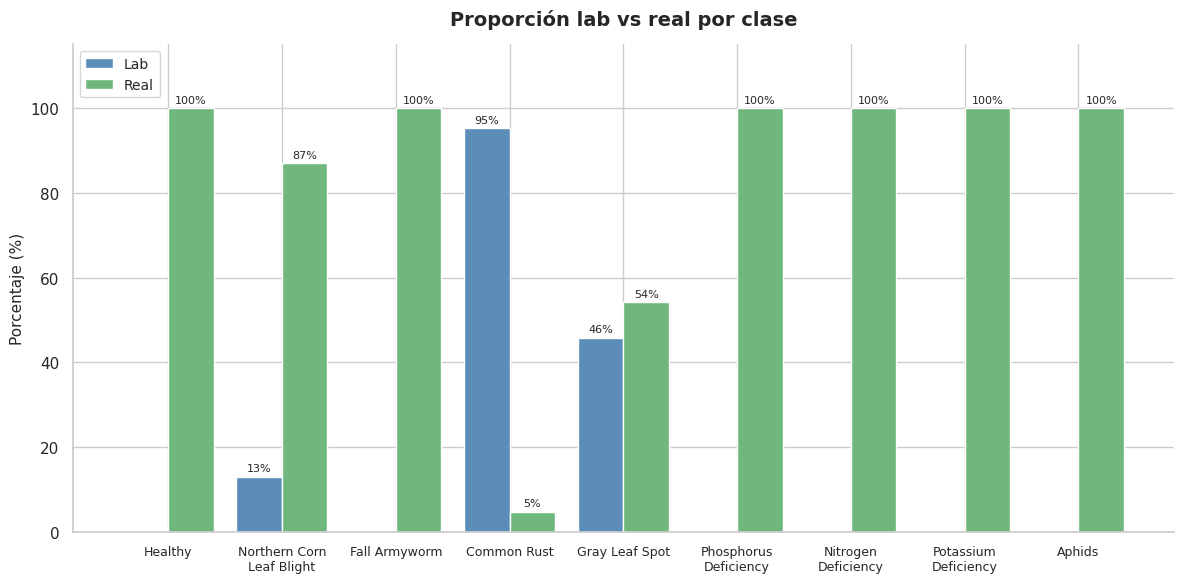

In [4]:
df_origen = df[["label", "lab", "real", "total"]].copy()
df_origen["pct_lab"]  = (df_origen["lab"]  / df_origen["total"] * 100).round(1)
df_origen["pct_real"] = (df_origen["real"] / df_origen["total"] * 100).round(1)

print("Proporción lab / real por clase:\n")
print(df_origen[["label", "lab", "pct_lab", "real", "pct_real", "total"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(df_origen))
w = 0.4

b_lab  = ax.bar(x - w/2, df_origen["pct_lab"],  width=w, label="Lab",  color="#5B8DB8", edgecolor="white")
b_real = ax.bar(x + w/2, df_origen["pct_real"], width=w, label="Real", color="#70B77E", edgecolor="white")

for bar in list(b_lab) + list(b_real):
    h = bar.get_height()
    if h > 2:
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.8,
                f"{h:.0f}%", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(df_origen["label"], fontsize=9)
ax.set_ylabel("Porcentaje (%)", fontsize=11)
ax.set_title("Proporción lab vs real por clase", fontsize=14, fontweight="bold", pad=14)
ax.set_ylim(0, 115)
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("../tmp/eda_02_lab_vs_real.png", dpi=150, bbox_inches="tight")
plt.show()

---

## 1.4 Análisis de resolución y dimensiones

Las redes neuronales convolucionales requieren tensores de entrada con dimensiones fijas (p.ej. 224×224 px para MobileNetV3). Conocer las dimensiones originales ayuda a entender cuánta información se perderá o distorsionará durante el redimensionamiento (*resizing*), y si existen imágenes con proporciones o tamaños anómalos.

Se usa un **muestreo estratificado** de hasta 400 imágenes por clase para acelerar el análisis sin perder representatividad.

Total de imágenes encontradas: 25,284
Muestra para análisis de dimensiones: 3,143 imágenes


Leyendo dimensiones:   0%|          | 0/3143 [00:00<?, ?it/s]

        width  height     mpx  aspect
count  3143.0  3143.0  3143.0  3143.0
mean    976.7   926.5     1.9     1.0
std    1138.6   961.7     4.2     0.3
min      33.0    33.0     0.0     0.3
25%     256.0   256.0     0.1     1.0
50%     640.0   640.0     0.4     1.0
75%     768.0  1024.0     0.8     1.0
max    5184.0  5120.0    20.2     4.2


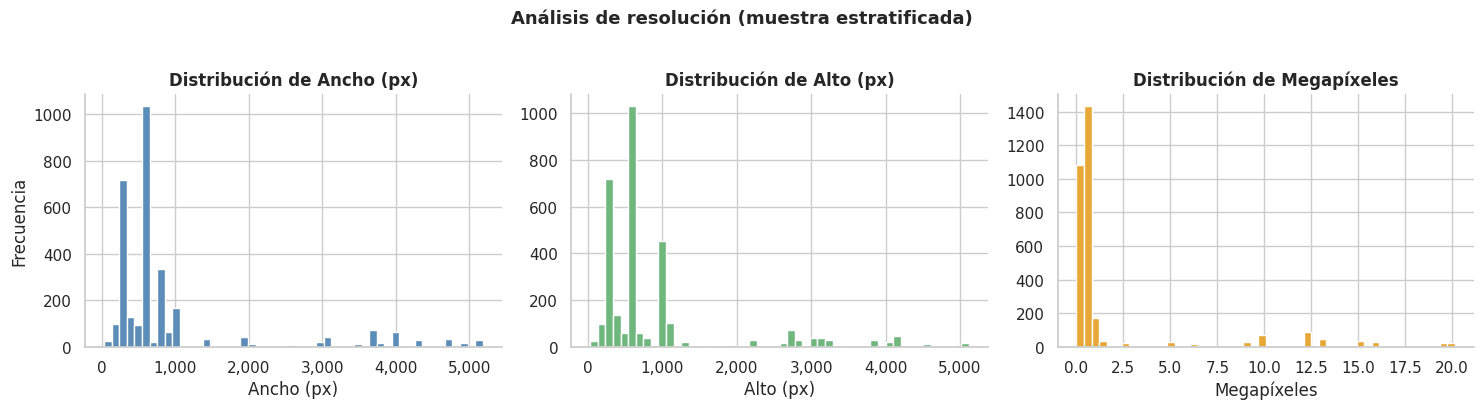


Ancho  — min: 33  max: 5,184  mediana: 640
Alto   — min: 33  max: 5,120  mediana: 640
Mpx    — min: 0.001  max: 20.155  mediana: 0.410
Aspect — min: 0.34  max: 4.17  mediana: 1.00


In [5]:
from PIL import Image
import random
from tqdm.auto import tqdm

all_images = [p for p in CLEAN_DIR.rglob("*") if p.suffix.lower() in IMG_EXTS]
print(f"Total de imágenes encontradas: {len(all_images):,}")

# Muestreo estratificado: hasta 400 por clase
SAMPLE_PER_CLASS = 400
sampled = []
for class_dir in CLEAN_DIR.iterdir():
    if not class_dir.is_dir():
        continue
    imgs = [p for p in class_dir.rglob("*") if p.suffix.lower() in IMG_EXTS]
    if len(imgs) > SAMPLE_PER_CLASS:
        imgs = random.sample(imgs, SAMPLE_PER_CLASS)
    sampled.extend(imgs)

print(f"Muestra para análisis de dimensiones: {len(sampled):,} imágenes")

dim_records = []
errors = []
for path in tqdm(sampled, desc="Leyendo dimensiones"):
    try:
        with Image.open(path) as img:
            w, h = img.size
        rel = path.relative_to(CLEAN_DIR).parts
        clase = rel[0]
        tipo  = rel[1] if len(rel) > 1 else "?"
        dim_records.append({
            "clase":  clase,
            "tipo":   tipo,
            "width":  w,
            "height": h,
            "mpx":    round(w * h / 1_000_000, 3),
            "aspect": round(w / h, 3),
        })
    except Exception as e:
        errors.append((str(path), str(e)))

df_dim = pd.DataFrame(dim_records)
if errors:
    print(f"Errores al leer: {len(errors)}")
print(df_dim.describe().round(1))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df_dim["width"],  bins=50, color="#5B8DB8", edgecolor="white")
axes[0].set_title("Distribución de Ancho (px)", fontweight="bold")
axes[0].set_xlabel("Ancho (px)")
axes[0].set_ylabel("Frecuencia")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

axes[1].hist(df_dim["height"], bins=50, color="#70B77E", edgecolor="white")
axes[1].set_title("Distribución de Alto (px)", fontweight="bold")
axes[1].set_xlabel("Alto (px)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

axes[2].hist(df_dim["mpx"], bins=50, color="#E8A838", edgecolor="white")
axes[2].set_title("Distribución de Megapíxeles", fontweight="bold")
axes[2].set_xlabel("Megapíxeles")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Análisis de resolución (muestra estratificada)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../tmp/eda_03_resoluciones.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nAncho  — min: {df_dim['width'].min():,}  max: {df_dim['width'].max():,}  mediana: {df_dim['width'].median():,.0f}")
print(f"Alto   — min: {df_dim['height'].min():,}  max: {df_dim['height'].max():,}  mediana: {df_dim['height'].median():,.0f}")
print(f"Mpx    — min: {df_dim['mpx'].min():.3f}  max: {df_dim['mpx'].max():.3f}  mediana: {df_dim['mpx'].median():.3f}")
print(f"Aspect — min: {df_dim['aspect'].min():.2f}  max: {df_dim['aspect'].max():.2f}  mediana: {df_dim['aspect'].median():.2f}")

---

## 1.5 Análisis de calidad de imagen

Se evalúan tres métricas automáticas sobre la muestra estratificada generada en la sección anterior:

- **Desenfoque:** varianza del Laplaciano sobre la versión en escala de grises. Valores bajos (< 100) indican falta de bordes detectables — imagen borrosa.
- **Subexposición:** brillo medio (escala de grises) < 40 → imagen muy oscura / subexpuesta.
- **Sobreexposición:** brillo medio > 230 → imagen muy clara / saturada.

Estas métricas no son absolutas (una imagen de fondo negro puede tener brillo bajo siendo perfectamente válida), pero permiten identificar outliers sistemáticos por clase.

Analizando calidad:   0%|          | 0/3143 [00:00<?, ?it/s]

Imágenes analizadas: 3,143

Resumen de problemas de calidad:
  Borrosas       (blur_var < 100.0):   540  (17.2%)
  Oscuras/subexp (brightness < 40.0): 0   (0.0%)
  Sobreexpuestas (brightness > 230.0): 0  (0.0%)


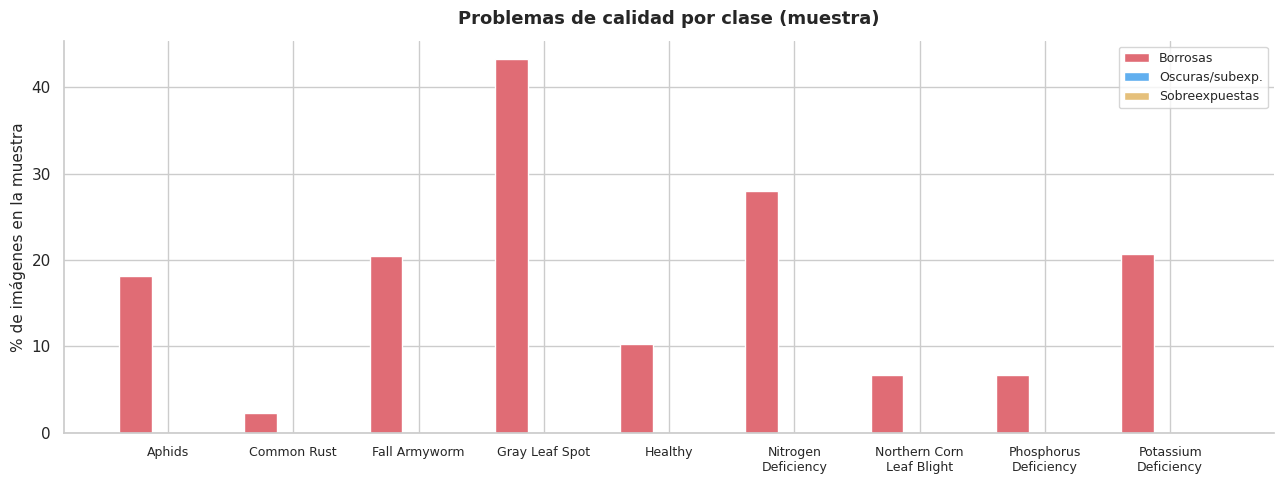

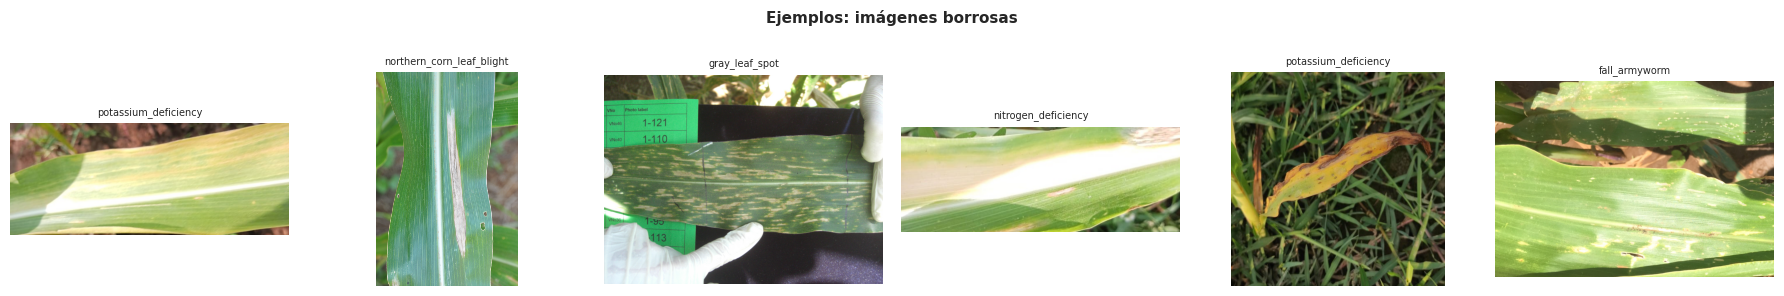

No se encontraron imágenes con: Ejemplos: imágenes oscuras / subexpuestas
No se encontraron imágenes con: Ejemplos: imágenes sobreexpuestas


In [6]:
BLUR_THRESHOLD    = 100.0
DARK_THRESHOLD    = 40.0
OVEREXP_THRESHOLD = 230.0

quality_records = []

for path in tqdm(sampled, desc="Analizando calidad"):
    try:
        img_bgr = cv2.imread(str(path))
        if img_bgr is None:
            continue
        gray       = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
        blur_var   = cv2.Laplacian(gray, cv2.CV_64F).var()
        brightness = float(gray.mean())
        clase      = path.relative_to(CLEAN_DIR).parts[0]
        quality_records.append({
            "clase":      clase,
            "path":       str(path),
            "blur_var":   round(blur_var, 2),
            "brightness": round(brightness, 2),
            "is_blurry":  blur_var < BLUR_THRESHOLD,
            "is_dark":    brightness < DARK_THRESHOLD,
            "is_overexp": brightness > OVEREXP_THRESHOLD,
        })
    except Exception:
        pass

df_q = pd.DataFrame(quality_records)
print(f"Imágenes analizadas: {len(df_q):,}\n")
print("Resumen de problemas de calidad:")
print(f"  Borrosas       (blur_var < {BLUR_THRESHOLD}):   {df_q['is_blurry'].sum():,}  ({df_q['is_blurry'].mean()*100:.1f}%)")
print(f"  Oscuras/subexp (brightness < {DARK_THRESHOLD}): {df_q['is_dark'].sum():,}   ({df_q['is_dark'].mean()*100:.1f}%)")
print(f"  Sobreexpuestas (brightness > {OVEREXP_THRESHOLD}): {df_q['is_overexp'].sum():,}  ({df_q['is_overexp'].mean()*100:.1f}%)")

# Gráfico por clase
quality_by_class = df_q.groupby("clase")[["is_blurry", "is_dark", "is_overexp"]].mean() * 100

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(quality_by_class))
w = 0.26
labels_q = [LABEL_MAP.get(c, c) for c in quality_by_class.index]

ax.bar(x - w,   quality_by_class["is_blurry"],  width=w, label="Borrosas",        color="#E06C75", edgecolor="white")
ax.bar(x,       quality_by_class["is_dark"],     width=w, label="Oscuras/subexp.", color="#61AFEF", edgecolor="white")
ax.bar(x + w,   quality_by_class["is_overexp"],  width=w, label="Sobreexpuestas",  color="#E5C07B", edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(labels_q, fontsize=9)
ax.set_ylabel("% de imágenes en la muestra", fontsize=11)
ax.set_title("Problemas de calidad por clase (muestra)", fontsize=13, fontweight="bold", pad=12)
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("../tmp/eda_04_calidad.png", dpi=150, bbox_inches="tight")
plt.show()

# Ejemplos visuales de imágenes con problemas
def show_flagged_examples(df_quality, flag_col, title, n=6):
    flagged = df_quality[df_quality[flag_col]]["path"].tolist()
    if not flagged:
        print(f"No se encontraron imágenes con: {title}")
        return
    sample = random.sample(flagged, min(n, len(flagged)))
    fig, axes = plt.subplots(1, len(sample), figsize=(3 * len(sample), 3))
    if len(sample) == 1:
        axes = [axes]
    for ax, p in zip(axes, sample):
        img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(Path(p).relative_to(CLEAN_DIR).parts[0], fontsize=7)
        ax.axis("off")
    fig.suptitle(title, fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.show()

show_flagged_examples(df_q, "is_blurry",  "Ejemplos: imágenes borrosas")
show_flagged_examples(df_q, "is_dark",    "Ejemplos: imágenes oscuras / subexpuestas")
show_flagged_examples(df_q, "is_overexp", "Ejemplos: imágenes sobreexpuestas")

---

## 1.6 Detección de duplicados y limpieza

Los duplicados fueron identificados y eliminados durante la etapa de limpieza del dataset utilizando **hash perceptual (pHash)** con la librería `imagededup` (threshold = 0, solo copias exactas a nivel perceptual). El proceso se ejecuta por clase completa (lab + real juntos) y los resultados se almacenan en CSVs en `src/cleanup/results/`.

A continuación se cargan esos CSVs y se muestran estadísticas reales del proceso de deduplicación por clase y fuente de origen.

> **Lógica de acceso:**
> - **Servidor/local:** lee directamente desde `../src/cleanup/results/` del repositorio.
> - **Google Colab:** descarga un ZIP con los CSVs desde Drive (`GDRIVE_RESULTS_FILE_ID`) y lo extrae en `/content/cleanup_results/`.

In [7]:
import csv
import json
import re
from collections import defaultdict

#  Configuración 
GDRIVE_RESULTS_FILE_ID = "1Erz4TivvmEJRr1LHwzqq8-UCFGc8BErB"

#  Localizar carpeta de resultados 
_REPO_RESULTS  = Path("../src/cleanup/results")
_COLAB_RESULTS = Path("/content/cleanup_results")

if _REPO_RESULTS.exists():
    RESULTS_DIR = _REPO_RESULTS
    print(f"Entorno: servidor/local (resultados en {RESULTS_DIR.resolve()})")
else:
    # Google Colab: descargar ZIP de resultados desde Drive
    import gdown, zipfile
    ZIP_R = Path("/content/cleanup_results.zip")
    if not _COLAB_RESULTS.exists():
        if not ZIP_R.exists():
            print("Descargando resultados de duplicados desde Drive...")
            gdown.download(id=GDRIVE_RESULTS_FILE_ID, output=str(ZIP_R), quiet=False)
        print("Descomprimiendo resultados...")
        with zipfile.ZipFile(ZIP_R, "r") as zf:
            zf.extractall("/content/cleanup_results")
        ZIP_R.unlink()
        print("Listo.")
    # El ZIP puede contener una subcarpeta (ej. results/) — buscar dónde están los CSVs
    csv_candidates = list(_COLAB_RESULTS.rglob("duplicates_*.csv"))
    RESULTS_DIR = csv_candidates[0].parent if csv_candidates else _COLAB_RESULTS
    print(f"Entorno: Google Colab (resultados en {RESULTS_DIR.resolve()})")

#  Fuentes conocidas del proyecto 
KNOWN_SOURCES = [
    "corn_leaf_roboflow", "maize_africa", "maize_desease", "maize_field",
    "cropdg", "maize_nutrient", "multi_desease",
]

def extract_source(filepath: str) -> str:
    name = Path(filepath).stem
    for src in sorted(KNOWN_SOURCES, key=len, reverse=True):
        if src in name:
            return src
    return "unknown"

def clase_from_filename(filename: str) -> str:
    stem = Path(filename).stem  # duplicates_CLASE_20260608_160954
    return re.sub(r"_\d{8}_\d{6}$", "", stem.replace("duplicates_", ""))

#  Procesar todos los CSVs 
dup_summary = defaultdict(lambda: {"groups": 0, "eliminated": 0, "by_source": defaultdict(int)})

csv_files = sorted(RESULTS_DIR.glob("duplicates_*.csv"))
print(f"\nArchivos CSV encontrados: {len(csv_files)}")

for csv_path in csv_files:
    clase = clase_from_filename(csv_path.name)
    with open(csv_path, newline="", encoding="utf-8") as fh:
        reader = csv.DictReader(fh)
        for row in reader:
            dups = json.loads(row["duplicate_paths"])
            dup_summary[clase]["groups"] += 1
            dup_summary[clase]["eliminated"] += len(dups)
            for dup_path in dups:
                src = extract_source(dup_path)
                dup_summary[clase]["by_source"][src] += 1

#  Tabla resumen 
df_dups = pd.DataFrame([
    {
        "clase":      clase,
        "grupos":     info["groups"],
        "eliminados": info["eliminated"],
        "fuentes":    ", ".join(f"{s}:{n}" for s, n in sorted(info["by_source"].items())),
    }
    for clase, info in sorted(dup_summary.items())
])

total_elim   = df_dups["eliminados"].sum()
total_grupos = df_dups["grupos"].sum()

print(f"\nTotal de grupos de duplicados detectados: {total_grupos:,}")
print(f"Total de imágenes eliminadas:             {total_elim:,}\n")
print(df_dups.to_string(index=False))

Descargando resultados de duplicados desde Drive...


Downloading...
From: https://drive.google.com/uc?id=1Erz4TivvmEJRr1LHwzqq8-UCFGc8BErB
To: /content/cleanup_results.zip
100%|██████████| 95.5k/95.5k [00:00<00:00, 53.1MB/s]

Descomprimiendo resultados...
Listo.
Entorno: Google Colab (resultados en /content/cleanup_results/results)

Archivos CSV encontrados: 8

Total de grupos de duplicados detectados: 8,050
Total de imágenes eliminadas:             8,538

                    clase  grupos  eliminados                                       fuentes
              common_rust     971        1048             maize_field:1, multi_desease:1047
            fall_armyworm     548         958            maize_africa:25, multi_desease:933
           gray_leaf_spot     535         535             maize_desease:513, maize_field:22
                  healthy    1773        1774 cropdg:1, maize_africa:26, maize_desease:1747
northern_corn_leaf_blight    4223        4223                            maize_desease:4223


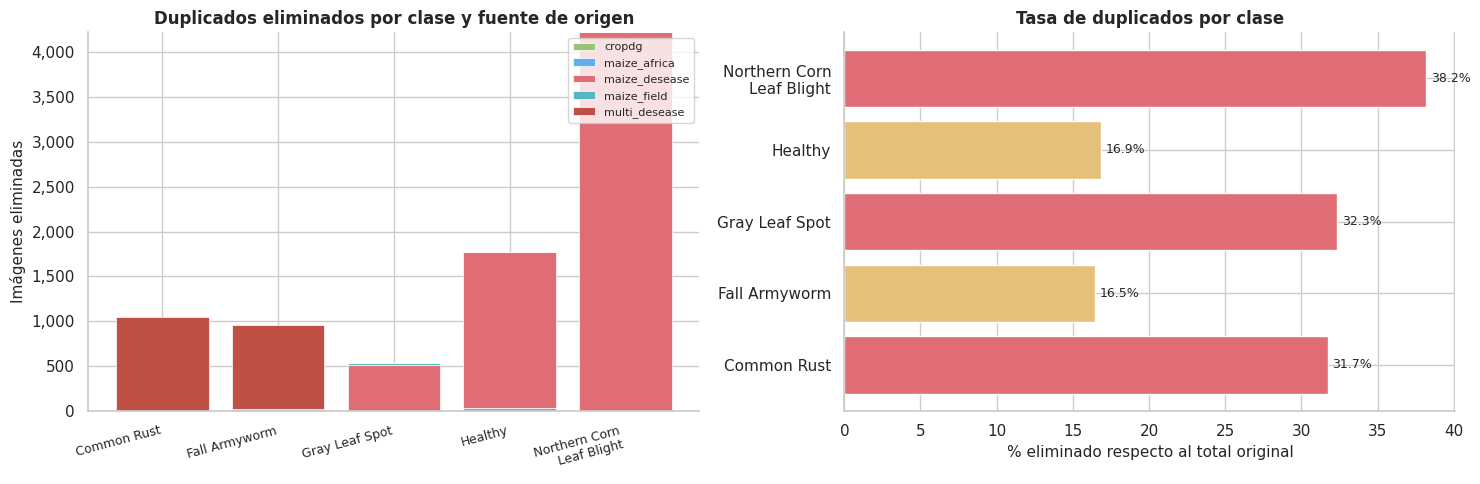


Método: pHash (imagededup), threshold=0 (solo copias exactas perceptualmente).
Total eliminado: 8,538 imágenes en 8,050 grupos.


In [8]:
#  Gráfico: duplicados eliminados por clase 
all_sources = sorted({src for info in dup_summary.values() for src in info["by_source"]})
clases_dup  = sorted(dup_summary.keys())

source_colors = {
    "maize_desease":  "#E06C75",
    "multi_desease":  "#BE5046",
    "maize_africa":   "#61AFEF",
    "maize_field":    "#56B6C2",
    "cropdg":         "#98C379",
    "corn_leaf_roboflow": "#E5C07B",
    "maize_nutrient": "#C678DD",
    "unknown":        "#ABB2BF",
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Izquierda: barras apiladas por fuente
bottom = np.zeros(len(clases_dup))
x = np.arange(len(clases_dup))
for src in all_sources:
    vals = [dup_summary[c]["by_source"].get(src, 0) for c in clases_dup]
    axes[0].bar(x, vals, bottom=bottom, label=src,
                color=source_colors.get(src, "#ABB2BF"), edgecolor="white", linewidth=0.5)
    bottom += np.array(vals)

axes[0].set_xticks(x)
axes[0].set_xticklabels([LABEL_MAP.get(c, c) for c in clases_dup], fontsize=9, rotation=15, ha="right")
axes[0].set_ylabel("Imágenes eliminadas", fontsize=11)
axes[0].set_title("Duplicados eliminados por clase y fuente de origen", fontsize=12, fontweight="bold")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
axes[0].legend(fontsize=8, loc="upper right")
axes[0].spines[["top", "right"]].set_visible(False)

# Derecha: % de duplicados respecto al total original (antes de limpiar)
df_pct = df.set_index("clase").reindex(clases_dup)
orig_totals = {
    c: df_pct.loc[c, "total"] + dup_summary[c]["eliminated"]
    for c in clases_dup if c in df_pct.index
}
pcts = [dup_summary[c]["eliminated"] / orig_totals[c] * 100 if c in orig_totals else 0
        for c in clases_dup]
bar_colors = ["#E06C75" if p > 30 else "#E5C07B" if p > 10 else "#70B77E" for p in pcts]
axes[1].barh([LABEL_MAP.get(c, c) for c in clases_dup], pcts, color=bar_colors, edgecolor="white")
axes[1].set_xlabel("% eliminado respecto al total original", fontsize=11)
axes[1].set_title("Tasa de duplicados por clase", fontsize=12, fontweight="bold")
axes[1].spines[["top", "right"]].set_visible(False)
for i, p in enumerate(pcts):
    axes[1].text(p + 0.3, i, f"{p:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("../tmp/eda_05_duplicados.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nMétodo: pHash (imagededup), threshold=0 (solo copias exactas perceptualmente).")
print(f"Total eliminado: {total_elim:,} imágenes en {total_grupos:,} grupos.")


---

## 1.7 Identificación de posibles sesgos

A partir de la distribución por clases y del análisis de origen (laboratorio vs campo), se identifican varios sesgos que pueden afectar el entrenamiento y la generalización del modelo.

CLASE                               RIESGO       DESCRIPCIÓN
----------------------------------------------------------------------------------------------------
common_rust                         Alto         Dominio de imágenes de laboratorio (95.4%)
  → 2,150 de 2,256 imágenes provienen de entorno controlado (PlantVillage via cropdg y maize_desease). El modelo p...

gray_leaf_spot                      Medio        Mezcla lab/real casi pareja, pero fuentes limitadas
  → 513 lab (todas de PlantVillage/cropdg) y 606 real (todas de maize_field). Poca variedad de fuentes para el ent...

northern_corn_leaf_blight           Medio        Alta proporción real, pero dominada por una sola fuente
  → 5,942 imágenes reales, de las cuales ~4,223 originalmente provenían de maize_africa (eliminados como duplicado...

aphids_pest                         Alto         Clase extremadamente subrepresentada (77 imágenes)
  → Solo 77 imágenes, todas de campo. Alta probabilidad de sobreajuste en esta clas

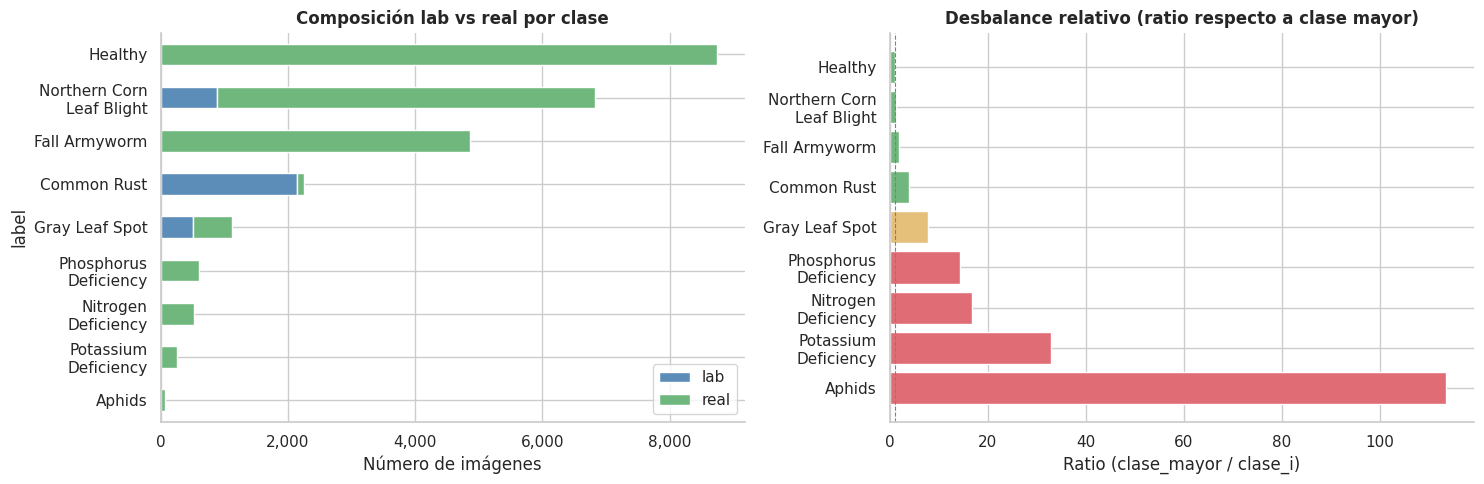


Ratio de desbalance máximo: 113.6x  ('aphids_pest' vs 'healthy')


In [9]:
biases = [
    {
        "clase":   "common_rust",
        "sesgo":   "Dominio de imágenes de laboratorio (95.4%)",
        "detalle": (
            "2,150 de 2,256 imágenes provienen de entorno controlado (PlantVillage via cropdg y maize_desease). "
            "El modelo podría aprender el fondo uniforme negro/blanco en lugar de los síntomas foliares reales. "
            "Solo 106 imágenes en campo."
        ),
        "riesgo": "Alto",
    },
    {
        "clase":   "gray_leaf_spot",
        "sesgo":   "Mezcla lab/real casi pareja, pero fuentes limitadas",
        "detalle": (
            "513 lab (todas de PlantVillage/cropdg) y 606 real (todas de maize_field). "
            "Poca variedad de fuentes para el entorno real."
        ),
        "riesgo": "Medio",
    },
    {
        "clase":   "northern_corn_leaf_blight",
        "sesgo":   "Alta proporción real, pero dominada por una sola fuente",
        "detalle": (
            "5,942 imágenes reales, de las cuales ~4,223 originalmente provenían de maize_africa (eliminados como duplicados). "
            "La representación geográfica podría ser limitada a condiciones de África subsahariana."
        ),
        "riesgo": "Medio",
    },
    {
        "clase":   "aphids_pest",
        "sesgo":   "Clase extremadamente subrepresentada (77 imágenes)",
        "detalle": (
            "Solo 77 imágenes, todas de campo. Alta probabilidad de sobreajuste en esta clase. "
            "Se evalúa ampliar con nuevas fuentes."
        ),
        "riesgo": "Alto",
    },
    {
        "clase":   "fall_armyworm",
        "sesgo":   "Dataset origen único (corn_leaf_roboflow)",
        "detalle": (
            "Las 4,858 imágenes provienen exclusivamente de Roboflow y ya vienen redimensionadas a 640×640 px "
            "con posible distorsión por stretch. Poca diversidad de captura."
        ),
        "riesgo": "Medio",
    },
    {
        "clase":   "deficiencias nutricionales",
        "sesgo":   "Fuente única y baja representación",
        "detalle": (
            "Nitrogen (523), Phosphorus (612) y Potassium (266) provienen exclusivamente de maize_nutrient. "
            "Todas en entorno real con resolución fija 640×640. Potassium especialmente escaso."
        ),
        "riesgo": "Medio-Alto",
    },
]

print(f"{'CLASE':<35} {'RIESGO':<12} {'DESCRIPCIÓN'}")
print("-" * 100)
for b in biases:
    print(f"{b['clase']:<35} {b['riesgo']:<12} {b['sesgo']}")
    print(f"  → {b['detalle'][:110]}...")
    print()

# Visualización: composición lab/real + ratio de desbalance
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

df_plot = df.set_index("label")[["lab", "real"]]
df_plot.plot(kind="barh", stacked=True, ax=axes[0],
             color=["#5B8DB8", "#70B77E"], edgecolor="white")
axes[0].set_title("Composición lab vs real por clase", fontweight="bold")
axes[0].set_xlabel("Número de imágenes")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[0].spines[["top", "right"]].set_visible(False)
axes[0].invert_yaxis()

ratio = df["total"].max() / df["total"]
ratio_df = pd.DataFrame({"label": df["label"], "ratio": ratio})
colors_r = ["#E06C75" if r > 10 else "#E5C07B" if r > 5 else "#70B77E"
            for r in ratio_df["ratio"]]
axes[1].barh(ratio_df["label"], ratio_df["ratio"], color=colors_r, edgecolor="white")
axes[1].axvline(1, color="gray", linestyle="--", linewidth=0.8)
axes[1].set_title("Desbalance relativo (ratio respecto a clase mayor)", fontweight="bold")
axes[1].set_xlabel("Ratio (clase_mayor / clase_i)")
axes[1].spines[["top", "right"]].set_visible(False)
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("../tmp/eda_06_sesgos.png", dpi=150, bbox_inches="tight")
plt.show()

max_idx = ratio.idxmax()
min_idx = ratio.idxmin()
print(f"\nRatio de desbalance máximo: {ratio.max():.1f}x  ({df.loc[max_idx, 'clase']!r} vs {df.loc[min_idx, 'clase']!r})")

---

## Conclusiones del EDA

### Hallazgos principales

1. **Desbalance severo:** La clase `healthy` (8,744) triplica a `northern_corn_leaf_blight` (6,830) y supera en **113×** a `aphids_pest` (77). Esto requiere muestreo ponderado o un techo máximo por clase durante el entrenamiento.

2. **Sesgo de dominio en `common_rust`:** El 95.4 % de las imágenes proviene de entorno controlado (fondo uniforme). El modelo podría aprender el fondo y no los síntomas. Se recomienda data augmentation agresivo (fondos aleatorios, variación de iluminación) y ampliar las imágenes de campo.

3. **Resolución heterogénea:** El dataset mezcla imágenes con resoluciones muy dispares. Las de `corn_leaf_roboflow` ya vienen fijas a 640×640 px. El pipeline de entrenamiento debe aplicar redimensionamiento consistente a la resolución de entrada del modelo.

4. **Duplicados controlados (8,538 eliminadas):** Se eliminaron **8,538 imágenes** agrupadas en **8,555 grupos** detectados por pHash. Las principales fuentes de duplicados fueron `maize_desease` (6,508), `multi_desease` (1,980) y `maize_africa` (51). El dataset actual en `data/clean/` es post-deduplicación, minimizando el riesgo de data leakage.

5. **Fuentes limitadas en clases pequeñas:** `aphids_pest`, `potassium_deficiency` y `nitrogen_deficiency` tienen una sola fuente de origen, lo que reduce la diversidad de condiciones de captura y aumenta el riesgo de sobreajuste a patrones específicos.

### Próximos pasos sugeridos

- Definir un techo de imágenes por clase (ej. 500, 1000 o 2000) para el conjunto de entrenamiento.
- Evaluar augmentation específico para `common_rust` (fondos aleatorios, crop agresivo).
- Explorar nuevas fuentes de datos para `aphids_pest` y deficiencias nutricionales.
- Considerar separar subconjuntos lab/real para evaluar la generalización del modelo en condiciones de campo.